# Cell typing – updated to match IHOPE project

WINDOWS VERSION

# Prep and preprocessing

In [47]:
import pandas as pd
from anndata import AnnData, read_h5ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#sklearn

Make sure you're in the parent directory:

In [57]:
import sys
from pathlib import Path

#Specific
PROJECT_ROOT = Path("D:/Emmy/IHOPE_SpatialProteomics")

Load, filter and normalize your raw data in csv format. Also, make sure to specify which file you're working with to facilitate later analysis. All subsequent naming of files is based on this.

In [154]:
from scripts import preprocessing
import importlib

# Reload to ensure notebook uses the latest version of the script
importlib.reload(preprocessing)

# Input path, here you need to write the entire raw data file name
csv_in = PROJECT_ROOT / "data" / "raw" / "IHOPE14_MedLN_TopLeft.csv"

# Keep track of which sample you're working on:
basename = "IHOPE14_MedLN_TopLeft"

# Output path, you can use this default format based on your basename:
csv_out = PROJECT_ROOT / "data" / "processed" / f"{basename}_cleaned_raw.csv"

# Clean raw CSV
preprocessing.clean_cell_columns(csv_in, csv_out)

Created directory: D:\Emmy\IHOPE_SpatialProteomics\data\processed
Cleaned CSV saved to: D:\Emmy\IHOPE_SpatialProteomics\data\processed\IHOPE14_MedLN_TopLeft_cleaned_raw.csv


If you don't need to preprocess any data, define base name anyway:

In [219]:
basename = "IHOPE14_MedLN_BottomLeft"

In [155]:
from scripts import preprocessing
import importlib

# Reload to ensure the latest version of the script is used
importlib.reload(preprocessing)

# Run preprocessing
input_file = PROJECT_ROOT / "data" / "processed" / f"{basename}_cleaned_raw.csv"
output_file = PROJECT_ROOT / "data" / "processed" / f"{basename}_cleaned_filtered.csv"

preprocessing.preprocess(input_file, output_file, plot=False)


ValueError: Missing required column: Area µm^2

**Normalize**

Choose between: "arcsinh", "z-score" and "none".

For arcsinh, you can specify a cofactor.

In [ ]:
from scripts.transforms import apply_transform

method = "arcsinh"
cofactor = 5.0    # Comment out if not applying arcsinh
input_file = PROJECT_ROOT / "data" / "processed" / f"{basename}_cleaned_filtered.csv"
output_file = PROJECT_ROOT / "data" / "processed" / f"{basename}_cleaned_filtered_arcsinh_cf5.0.csv"

df_out, markers, metadata, fig = apply_transform(
    input_file=input_file,
    method=method,
    cofactor=cofactor, # Comment out if not applying arcsinh
    output_file=output_file,
    save_plot=True
)

# Building Anndata and annotating marker positivity


If you want to start from a cleaned and normalized file:

In [4]:
basename = "IHOPE20_Spleen"

In [ ]:
from scripts.anndata_helpers import load_and_build_anndata, save_h5ad

# Read file and create AnnData object
filename = PROJECT_ROOT / "data" / "processed" / f"{basename}_cleaned_filtered_arcsinh_cf5.0.csv"
adata = load_and_build_anndata(filename)

In [ ]:
print("adata summary: ")
print(adata)
print("adata X shape: ")
print(adata.X.shape)
print("adata spatial data dimensions: ")
print(adata.obsm['spatial'].shape)
print("adata var: ")
print(adata.var)
print("adata var names: ")
print(adata.var_names)

Apply marker positivity thresholds (GMM intersections):

In [ ]:
from scripts.annotation import compute_positivity_matrix

# Annotate all cells with GMM-based positivity for canonical markers, fallback to percentile if unimodal
adata, thresholds, best_gmms = compute_positivity_matrix(
    adata,
    quantile=0.8,
    random_state=0
)

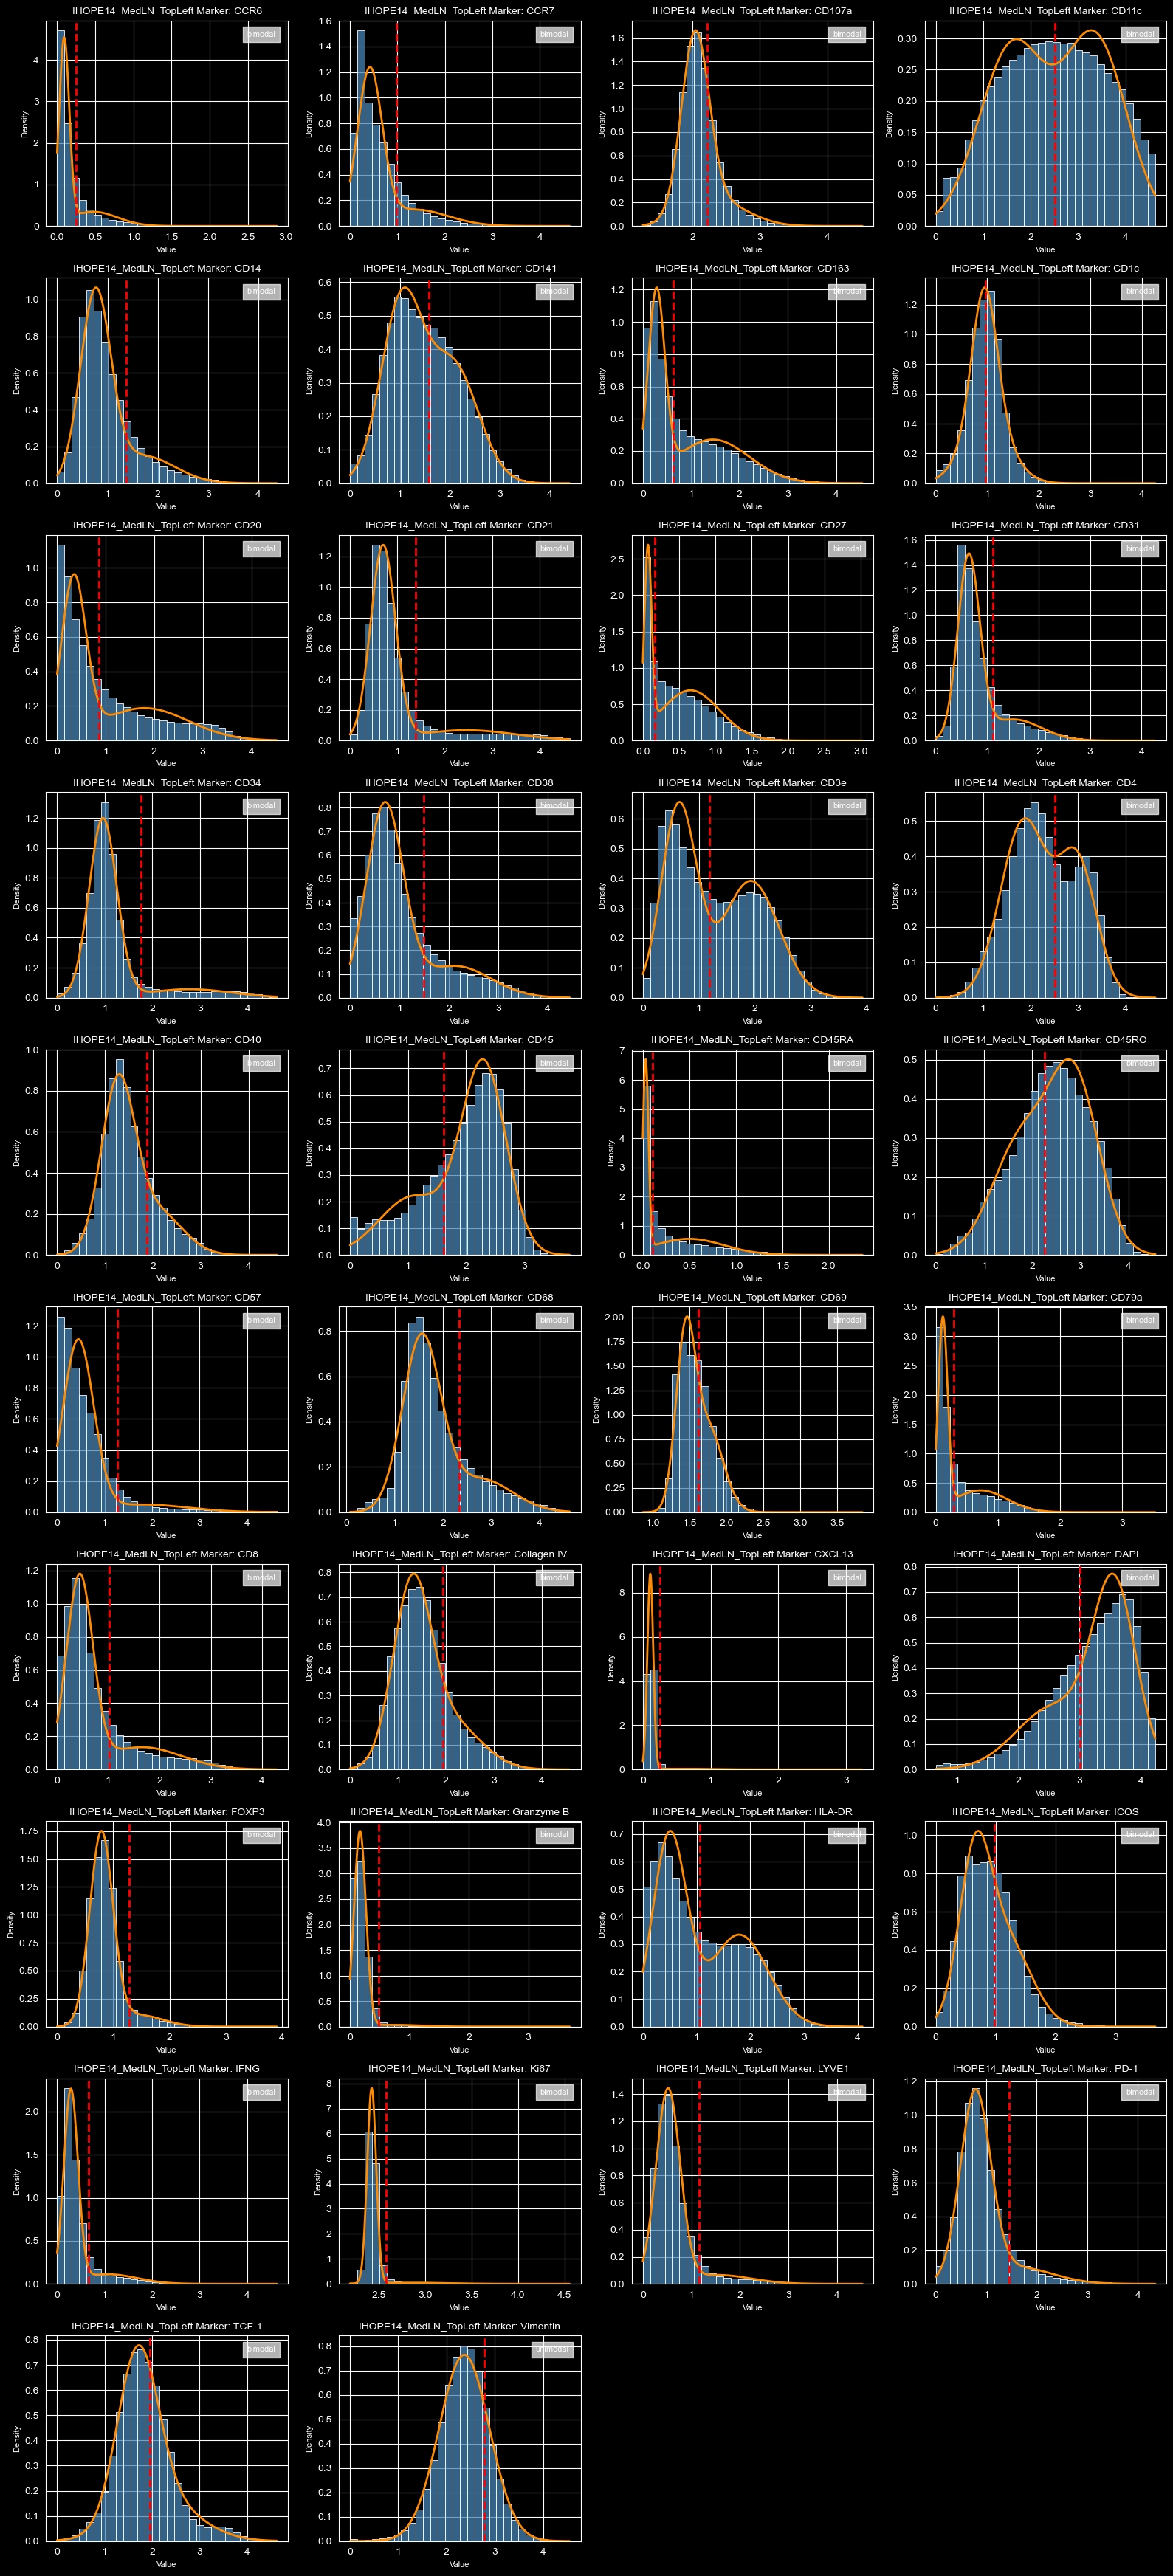

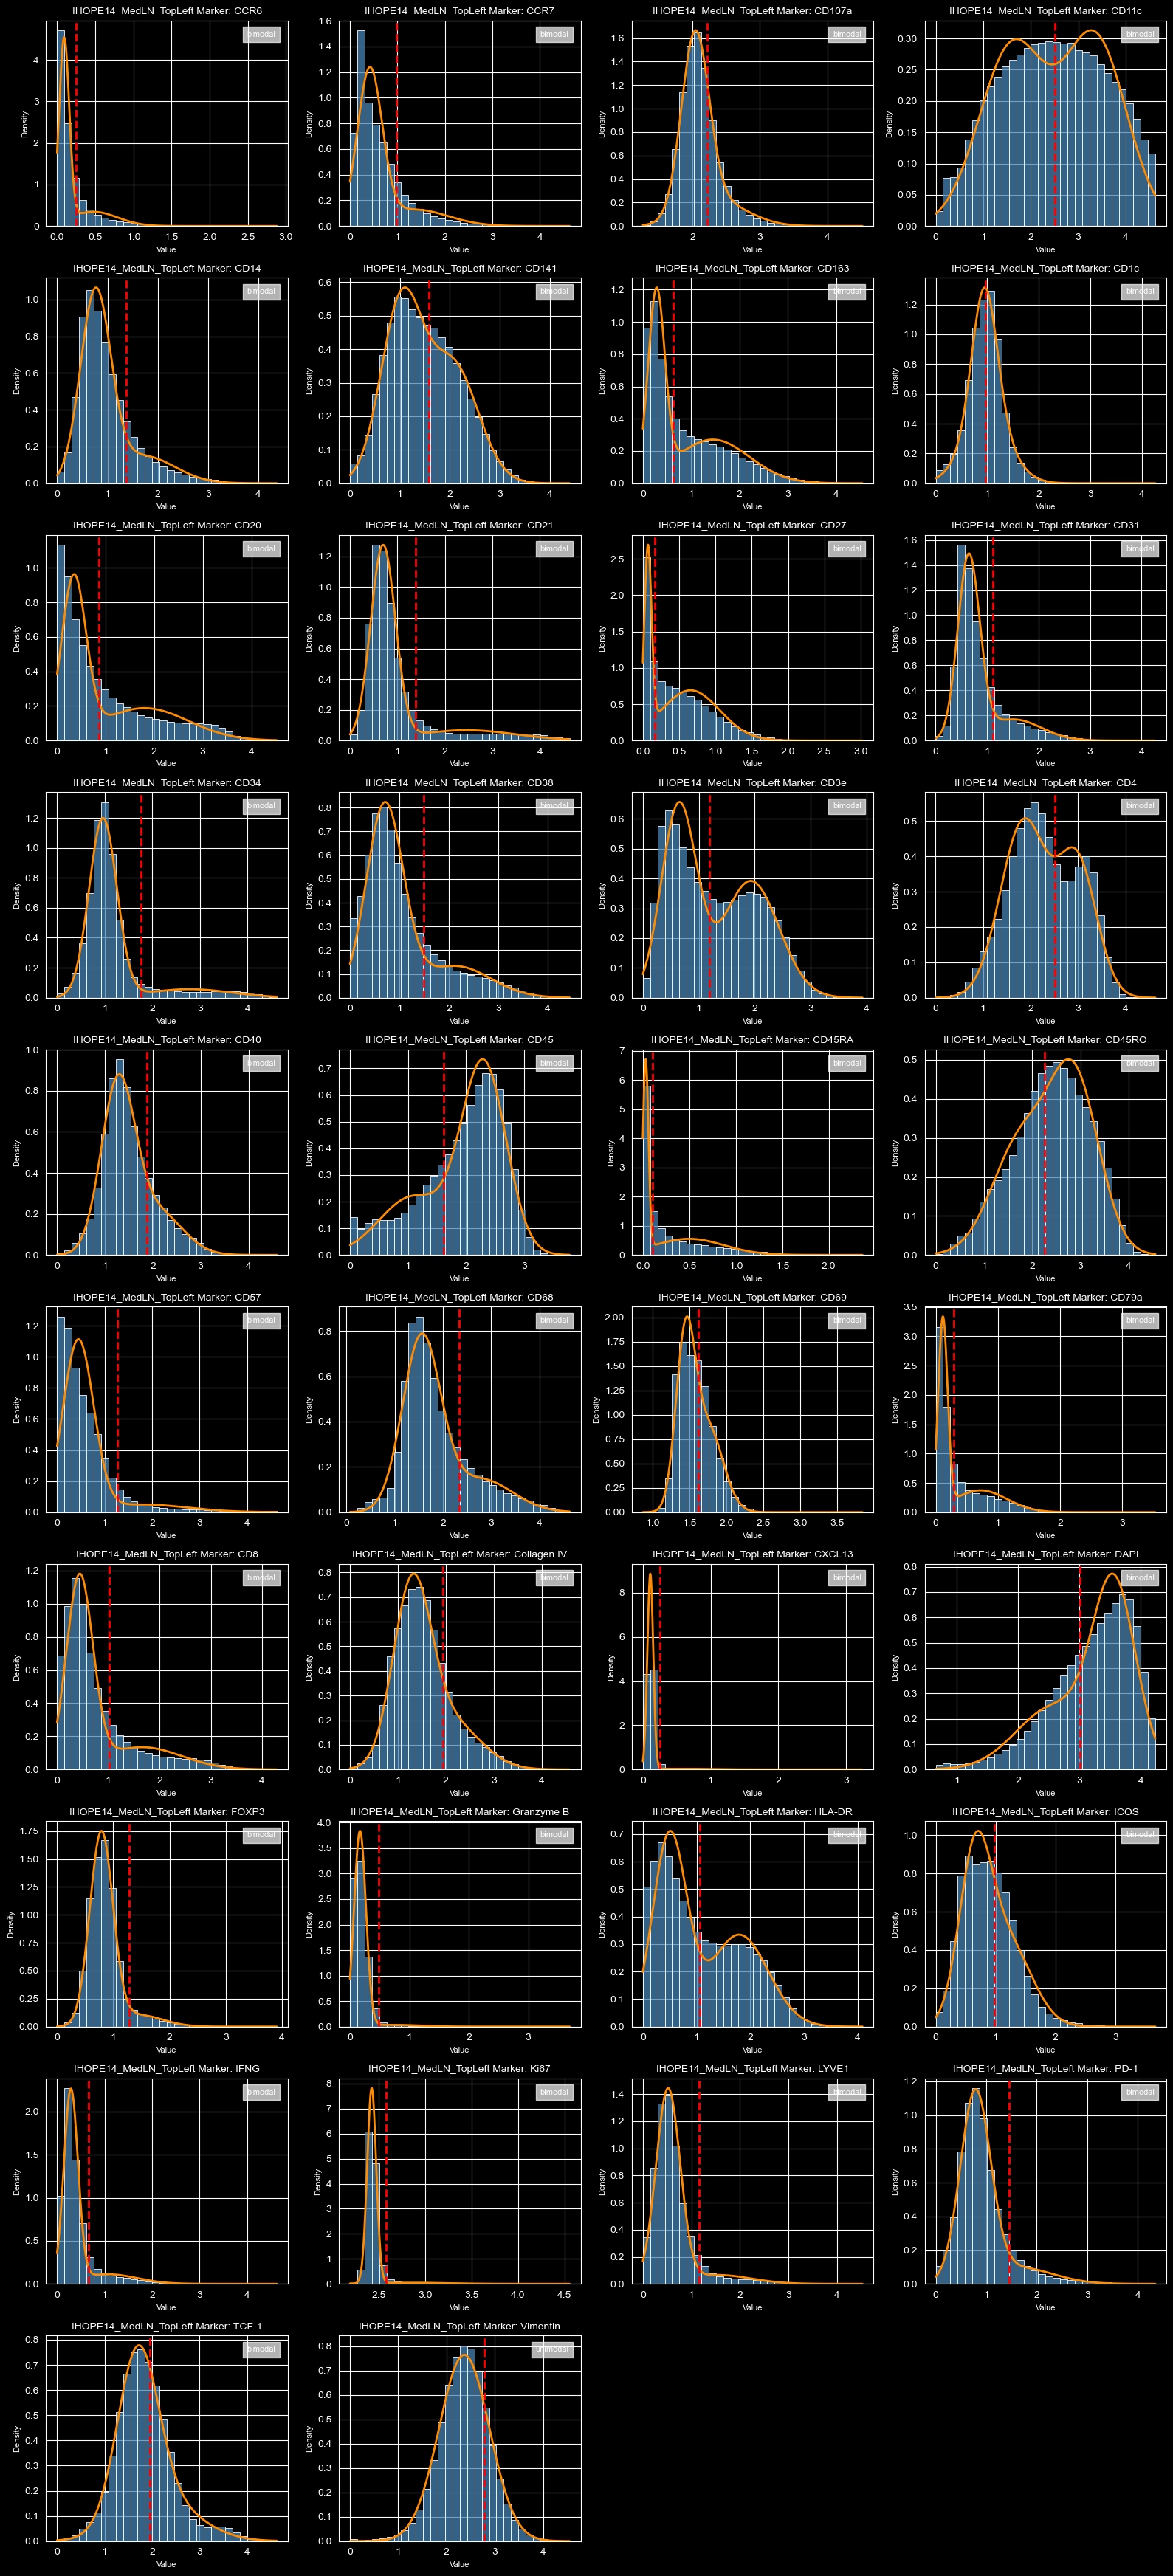

In [147]:
# Visualize the distributions and thresholds:
from scripts.annotation import plot_marker_gmm_adata
plot_marker_gmm_adata(adata,
                      thresholds,
                      best_gmms,
                      title_prefix=f"{basename} Marker: ",
                      save=False,
                      filename="GMM_histograms")

In [148]:
print(f"{basename}_GMM_marker_thresholds.png")

IHOPE14_MedLN_TopLeft_GMM_marker_thresholds


# Optional: add high/low levels to marker of interest.

Specify marker name, quantiles to label as low and high, and a recommended plot for visualization.


CD38 intensity tiers (restricted to CD38_pos cells)
  low_q  = 0.33  -> threshold = 1.8351
  high_q = 0.90 -> threshold = 2.8998
Counts:
  total cells:   452411
  CD38_pos:  204714
  CD38_low:  67557  (33.0%)
  CD38_mid:  116685  (57.0%)
  CD38_high: 20472  (10.0%)


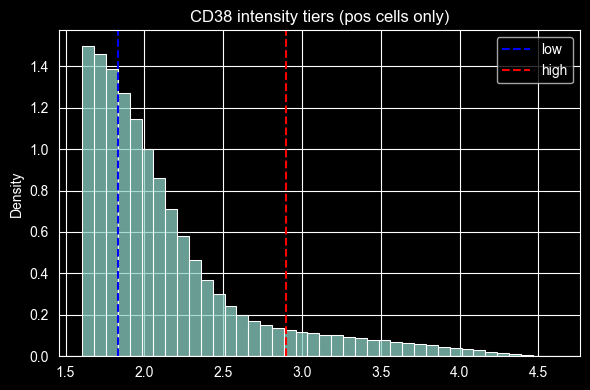

AnnData object with n_obs × n_vars = 452411 × 38
    obs: 'Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio', 'x', 'y', 'CCR6_pos', 'CCR7_pos', 'CD107a_pos', 'CD11c_pos', 'CD14_pos', 'CD141_pos', 'CD163_pos', 'CD1c_pos', 'CD20_pos', 'CD21_pos', 'CD27_pos', 'CD31_pos', 'CD34_pos', 'CD38_pos', 'CD3e_pos', 'CD4_pos', 'CD40_pos', 'CD45_pos', 'CD45RA_pos', 'CD45RO_pos', 'CD57_pos', 'CD68_pos', 'CD69_pos', 'CD79a_pos', 'CD8_pos', 'Collagen IV_pos', 'CXCL13_pos', 'DAPI_pos', 'FOXP3_pos', 'Granzyme B_pos', 'HLA-DR_pos', 'ICOS_pos', 'IFNG_pos', 'Ki67_pos', 'LYVE1_pos', 'PD-1_pos', 'TCF-1_pos', 'Vimentin_pos', 'CD38_low', 'CD38_mid', 'CD38_high'
    uns: 'thresholds', 'intensity_thresholds'
    obsm: 'spatial'

In [9]:
from scripts import annotation

annotation.add_intensity_tiers(
    adata,
    marker="CD38",
    low_q=0.33,
    high_q=0.9,
    plot=True
)


CD21 intensity tiers (restricted to CD21_pos cells)
  low_q  = 0.33  -> threshold = 2.5586
  high_q = 0.90 -> threshold = 3.8957
Counts:
  total cells:   452411
  CD21_pos:  50746
  CD21_low:  16746  (33.0%)
  CD21_mid:  28925  (57.0%)
  CD21_high: 5075  (10.0%)


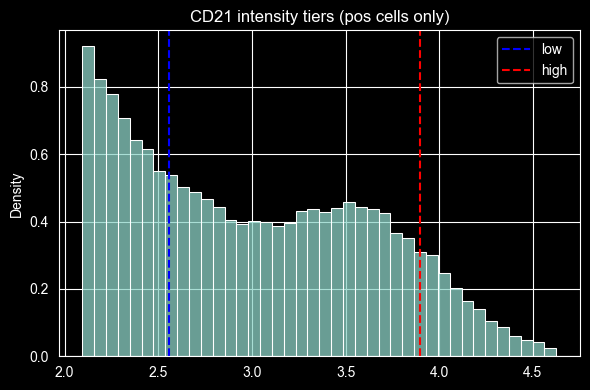

AnnData object with n_obs × n_vars = 452411 × 38
    obs: 'Object ID', 'Centroid X µm', 'Centroid Y µm', 'Area µm^2', 'Nucleus/Cell area ratio', 'x', 'y', 'CCR6_pos', 'CCR7_pos', 'CD107a_pos', 'CD11c_pos', 'CD14_pos', 'CD141_pos', 'CD163_pos', 'CD1c_pos', 'CD20_pos', 'CD21_pos', 'CD27_pos', 'CD31_pos', 'CD34_pos', 'CD38_pos', 'CD3e_pos', 'CD4_pos', 'CD40_pos', 'CD45_pos', 'CD45RA_pos', 'CD45RO_pos', 'CD57_pos', 'CD68_pos', 'CD69_pos', 'CD79a_pos', 'CD8_pos', 'Collagen IV_pos', 'CXCL13_pos', 'DAPI_pos', 'FOXP3_pos', 'Granzyme B_pos', 'HLA-DR_pos', 'ICOS_pos', 'IFNG_pos', 'Ki67_pos', 'LYVE1_pos', 'PD-1_pos', 'TCF-1_pos', 'Vimentin_pos', 'CD38_low', 'CD38_mid', 'CD38_high', 'CD21_low', 'CD21_mid', 'CD21_high'
    uns: 'thresholds', 'intensity_thresholds'
    obsm: 'spatial'

In [10]:
from scripts import annotation

annotation.add_intensity_tiers(
    adata,
    marker="CD21",
    low_q=0.33,
    high_q=0.9,
    plot=True
)

# Save anndata object with progress so far

In [149]:
# Save AnnData as h5ad
h5adpath = PROJECT_ROOT / "data" / "processed" / "anndata" / f"{basename}_filtered_arcsinh_cf5_GMM.h5ad"
save_h5ad(adata, h5adpath)

To load the same anndata:

In [228]:
import anndata as ad

h5adpath = PROJECT_ROOT / "data" / "processed" / "anndata" / f"{basename}_filtered_arcsinh_cf5_GMM.h5ad"

adata = ad.read_h5ad(h5adpath)

# Rule-based cell typing

Each cell type will correspond to a column in the AnnData object, with a boolean True/False for every cell type in every cell.

In [150]:
import scripts
import scripts.celltype_rules_IHOPE
import importlib

importlib.reload(scripts.celltype_rules_IHOPE)

<module 'scripts.celltype_rules_IHOPE' from 'D:\\Emmy\\IHOPE_SpatialProteomics\\scripts\\celltype_rules_IHOPE.py'>

In [1]:
#If you need to load anndata:
import anndata as ad

basename = "IHOPE20_Spleen"
adata = ad.read_h5ad(
    f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM.h5ad"
)

Cell typing:

In [151]:
from scripts.celltype_rules_IHOPE import assign_cell_types_bool_IHOPE

adata = assign_cell_types_bool_IHOPE(adata)


Total cells: 399569

Level — type:
  type_B: 49687 (12.4% of total)
  type_T: 87907 (22.0% of total)
  type_NK: 694 (0.2% of total)
  type_Myeloid: 41398 (10.4% of total)
  type_Stromal: 29204 (7.3% of total)
  type_Endothelial: 61143 (15.3% of total)
  type_unclassified: 137890 (34.5% of total)

Level — intermediate:
  intermediate_CD4_T: 45812 (11.5% of total)
  intermediate_CD8_T: 16369 (4.1% of total)
  intermediate_T_naive: 2829 (0.7% of total)
  intermediate_T_memory: 25588 (6.4% of total)
  intermediate_B_naive: 549 (0.1% of total)
  intermediate_B_memory: 23962 (6.0% of total)

Level — subtype:
  subtype_B_GC: 5336 (1.3% of total)
  subtype_B_plasmablast: 9053 (2.3% of total)
  subtype_TN_CD4: 2168 (0.5% of total)
  subtype_TN_CD8: 183 (0.0% of total)
  subtype_TCM_CD4: 16540 (4.1% of total)
  subtype_TCM_CD8: 906 (0.2% of total)
  subtype_TEM_CD4: 26071 (6.5% of total)
  subtype_TEM_CD8: 13575 (3.4% of total)
  subtype_TEMRA_CD4: 1033 (0.3% of total)
  subtype_TEMRA_CD8: 1705 

Save anndata with cell type information:

In [152]:
from scripts.anndata_helpers import save_h5ad

h5adpath = PROJECT_ROOT / "data" / "processed" / "anndata" / f"{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes.h5ad"
save_h5ad(adata, h5adpath)

# Visual diagnostics

Some FACS-style plots to "diagnose" how the thresholds look:

In [18]:
from scripts.marker_plots import plot_marker_axes

plot_marker_axes(
    adata,
    x_marker="CD21",
    y_marker="CD38",
    base_mask="type_B",
    title="B cells: CD21 vs CD38 (intensity thresholds)"
)

NameError: name 'AnnData' is not defined

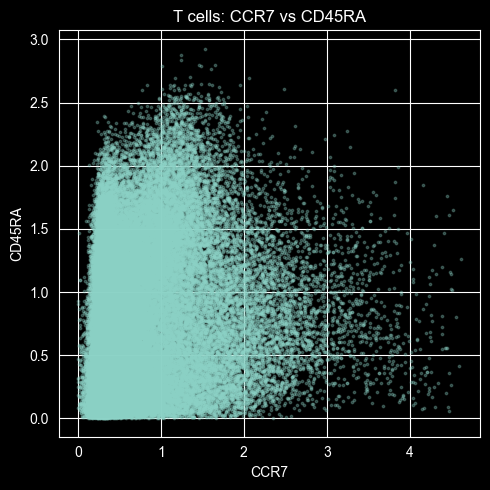

In [19]:
plot_marker_axes(
    adata,
    x_marker="CCR7",
    y_marker="CD45RA",
    base_mask="type_T",
    title="T cells: CCR7 vs CD45RA"
)

Heatmap of markers in cell types:

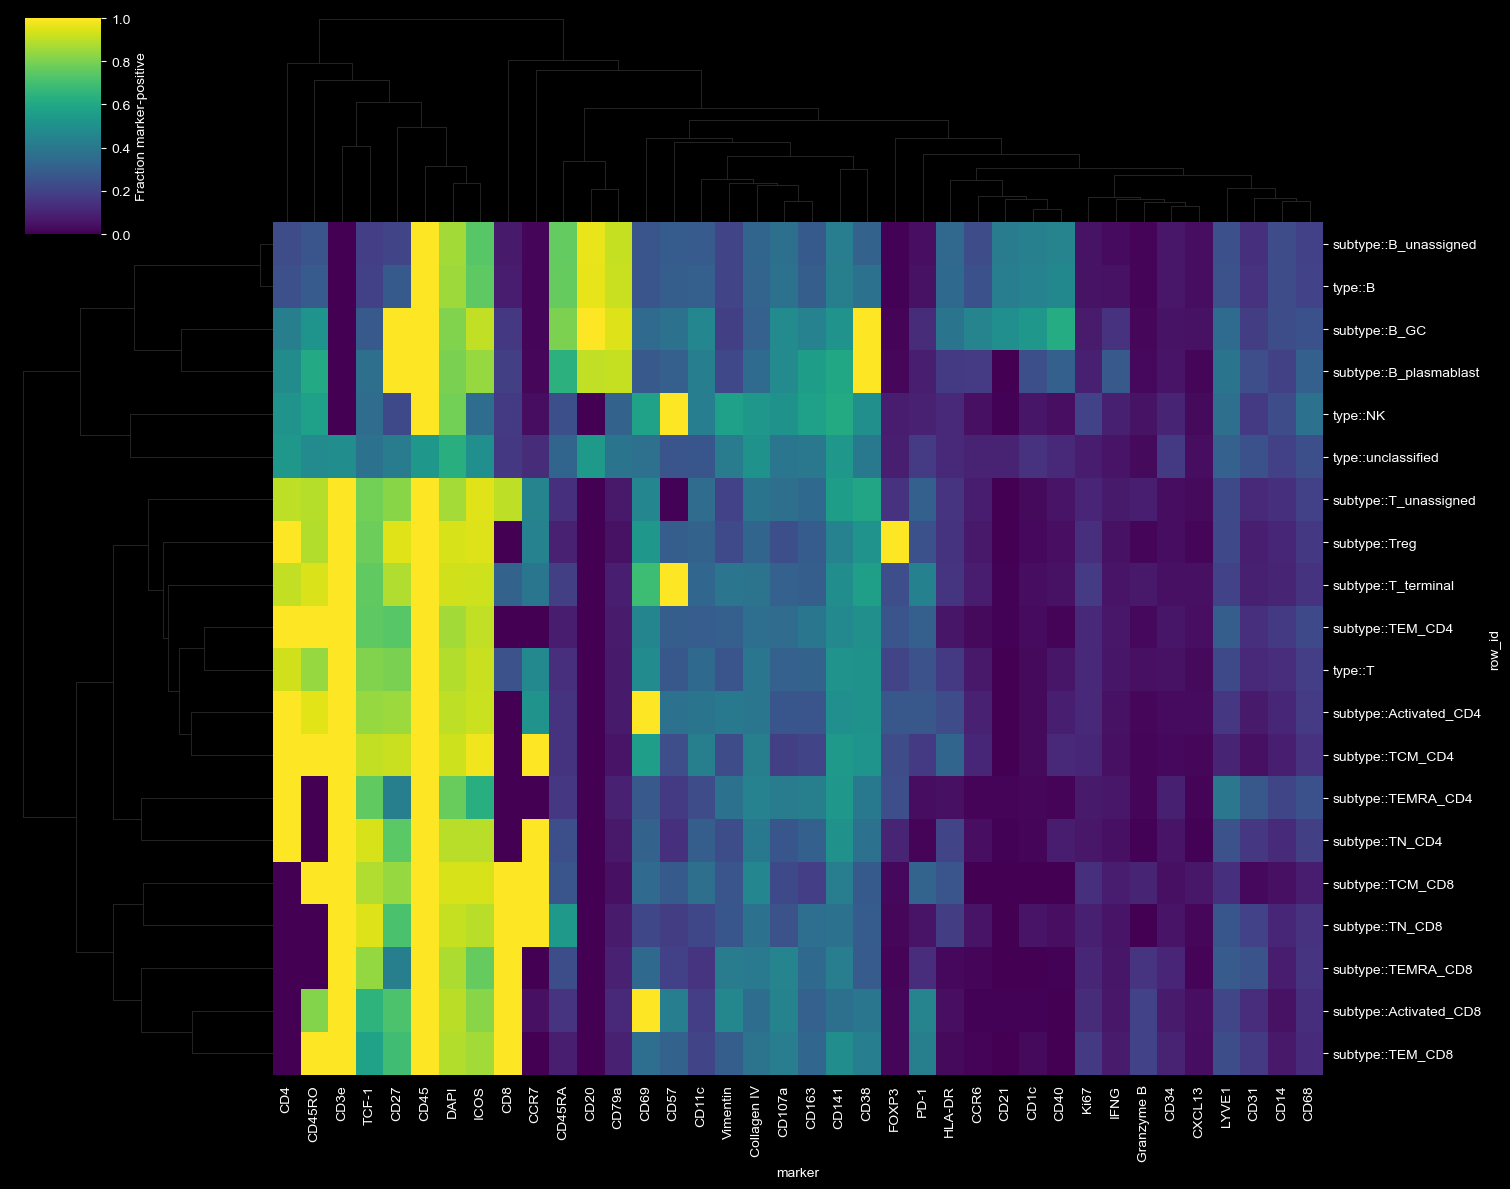

In [20]:
from scripts.plotting import clustered_marker_heatmap

# all cell type columns
celltype_cols = [
    c for c in adata.obs.columns
    if c.startswith(("type_", "state_", "subtype_"))
]

matrix = clustered_marker_heatmap(
    adata,
    celltype_cols=celltype_cols,
    min_cells=15,
    base_fig_width=10,
    fig_height=12,
    cmap="viridis",
)


# Spatial visualization

In [119]:
from importlib import reload
from scripts import spatial_plot
reload(scripts.spatial_plot)

<module 'scripts.spatial_plot' from 'D:\\Emmy\\IHOPE_SpatialProteomics\\scripts\\spatial_plot.py'>

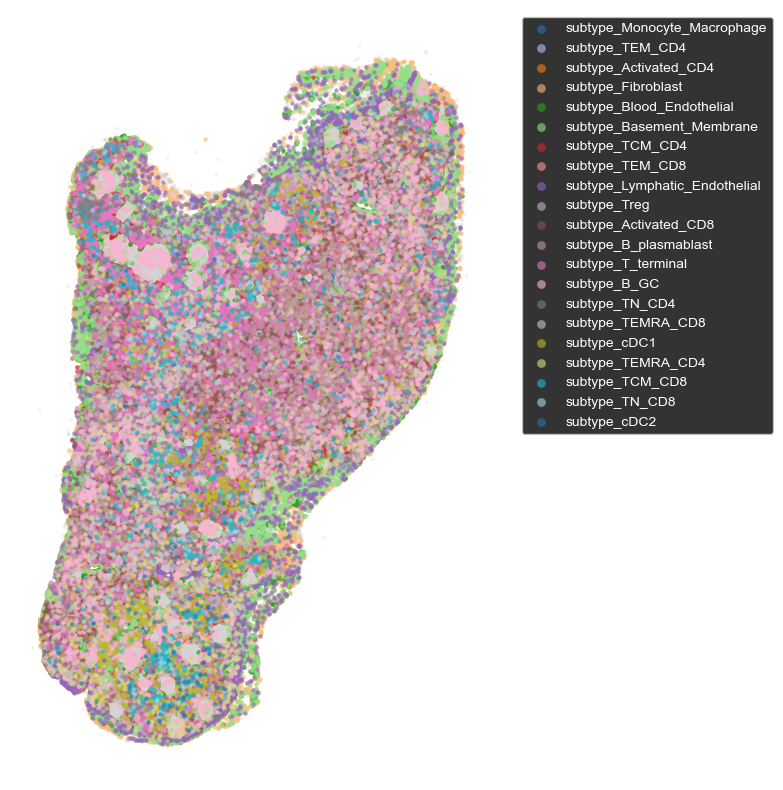

{'subtype_Monocyte_Macrophage': (0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765),
 'subtype_TEM_CD4': (0.6823529411764706,
  0.7803921568627451,
  0.9098039215686274),
 'subtype_Activated_CD4': (1.0, 0.4980392156862745, 0.054901960784313725),
 'subtype_Fibroblast': (1.0, 0.7333333333333333, 0.47058823529411764),
 'subtype_Blood_Endothelial': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313),
 'subtype_Basement_Membrane': (0.596078431372549,
  0.8745098039215686,
  0.5411764705882353),
 'subtype_TCM_CD4': (0.8392156862745098,
  0.15294117647058825,
  0.1568627450980392),
 'subtype_TEM_CD8': (1.0, 0.596078431372549, 0.5882352941176471),
 'subtype_Lymphatic_Endothelial': (0.5803921568627451,
  0.403921568627451,
  0.7411764705882353),
 'subtype_Treg': (0.7725490196078432, 0.6901960784313725, 0.8352941176470589),
 'subtype_Activated_CD8': (0.5490196078431373,
  0.33725490196078434,
  0.29411764705882354),
 'subtype_B_plasmablast': (0.7686274509803922,
  0.

In [153]:
from scripts.spatial_plot import spatial_celltype_plot

celltype_cols = [c for c in adata.obs.columns if c.startswith("subtype_") and not c.endswith ("unassigned")]

#or use this for all:
#[c for c in adata.obs.columns if c.startswith(("type_", "state_", "subtype_"))]

# Spatial plot
spatial_celltype_plot(adata, celltype_cols, min_cells=25)


In [121]:
print(f"{basename}_subtypes_spatial")

IHOPE14_MedLN_BottomRight_subtypes_spatial


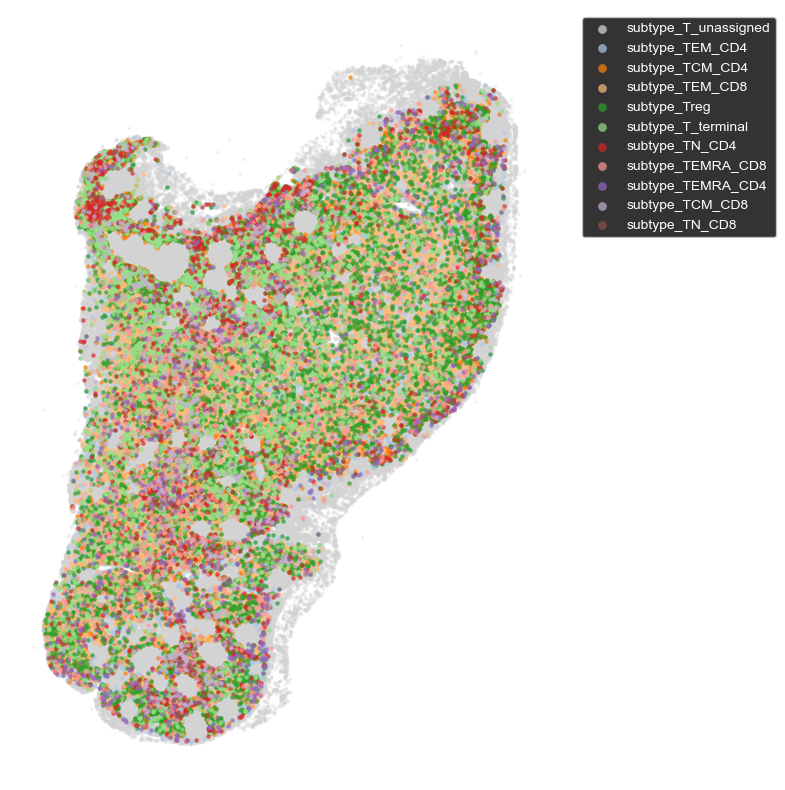

{'subtype_T_unassigned': (0.85, 0.85, 0.85),
 'subtype_TEM_CD4': (0.6823529411764706,
  0.7803921568627451,
  0.9098039215686274),
 'subtype_TCM_CD4': (1.0, 0.4980392156862745, 0.054901960784313725),
 'subtype_TEM_CD8': (1.0, 0.7333333333333333, 0.47058823529411764),
 'subtype_Treg': (0.17254901960784313,
  0.6274509803921569,
  0.17254901960784313),
 'subtype_T_terminal': (0.596078431372549,
  0.8745098039215686,
  0.5411764705882353),
 'subtype_TN_CD4': (0.8392156862745098,
  0.15294117647058825,
  0.1568627450980392),
 'subtype_TEMRA_CD8': (1.0, 0.596078431372549, 0.5882352941176471),
 'subtype_TEMRA_CD4': (0.5803921568627451,
  0.403921568627451,
  0.7411764705882353),
 'subtype_TCM_CD8': (0.7725490196078432,
  0.6901960784313725,
  0.8352941176470589),
 'subtype_TN_CD8': (0.5490196078431373,
  0.33725490196078434,
  0.29411764705882354)}

In [122]:
from scripts.spatial_plot import spatial_celltype_plot

# T cell subtype columns
t_subtypes = [c for c in adata.obs.columns if c.startswith("subtype_T")]

# Plot
spatial_celltype_plot(
    adata,
    celltype_cols=t_subtypes,
    min_cells=15,
    size=10,
    alpha=0.7
)


In [123]:
print(f"{basename}_subtypes_T_spatial")

IHOPE14_MedLN_BottomRight_subtypes_T_spatial


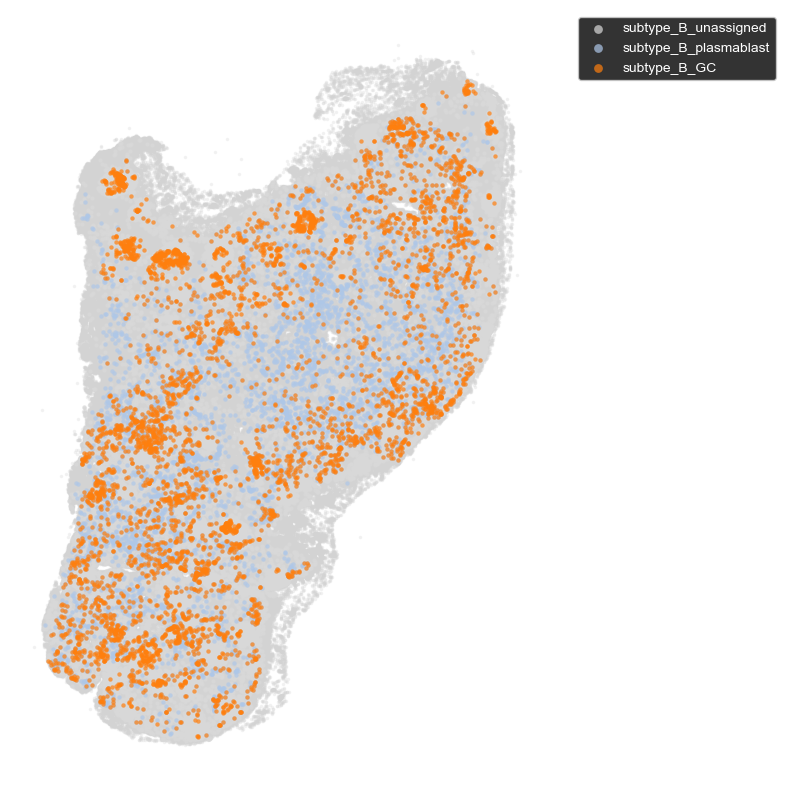

{'subtype_B_unassigned': (0.85, 0.85, 0.85),
 'subtype_B_plasmablast': (0.6823529411764706,
  0.7803921568627451,
  0.9098039215686274),
 'subtype_B_GC': (1.0, 0.4980392156862745, 0.054901960784313725)}

In [124]:
from scripts.spatial_plot import spatial_celltype_plot

# B cell subtype columns
b_subtypes = [c for c in adata.obs.columns if c.startswith("subtype_B_")]

# Plot
spatial_celltype_plot(
    adata,
    celltype_cols=b_subtypes,
    min_cells=15,
    size=10,
    alpha=0.7
)


In [125]:
print(f"{basename}_subtypes_B_spatial")


IHOPE14_MedLN_BottomRight_subtypes_B_spatial


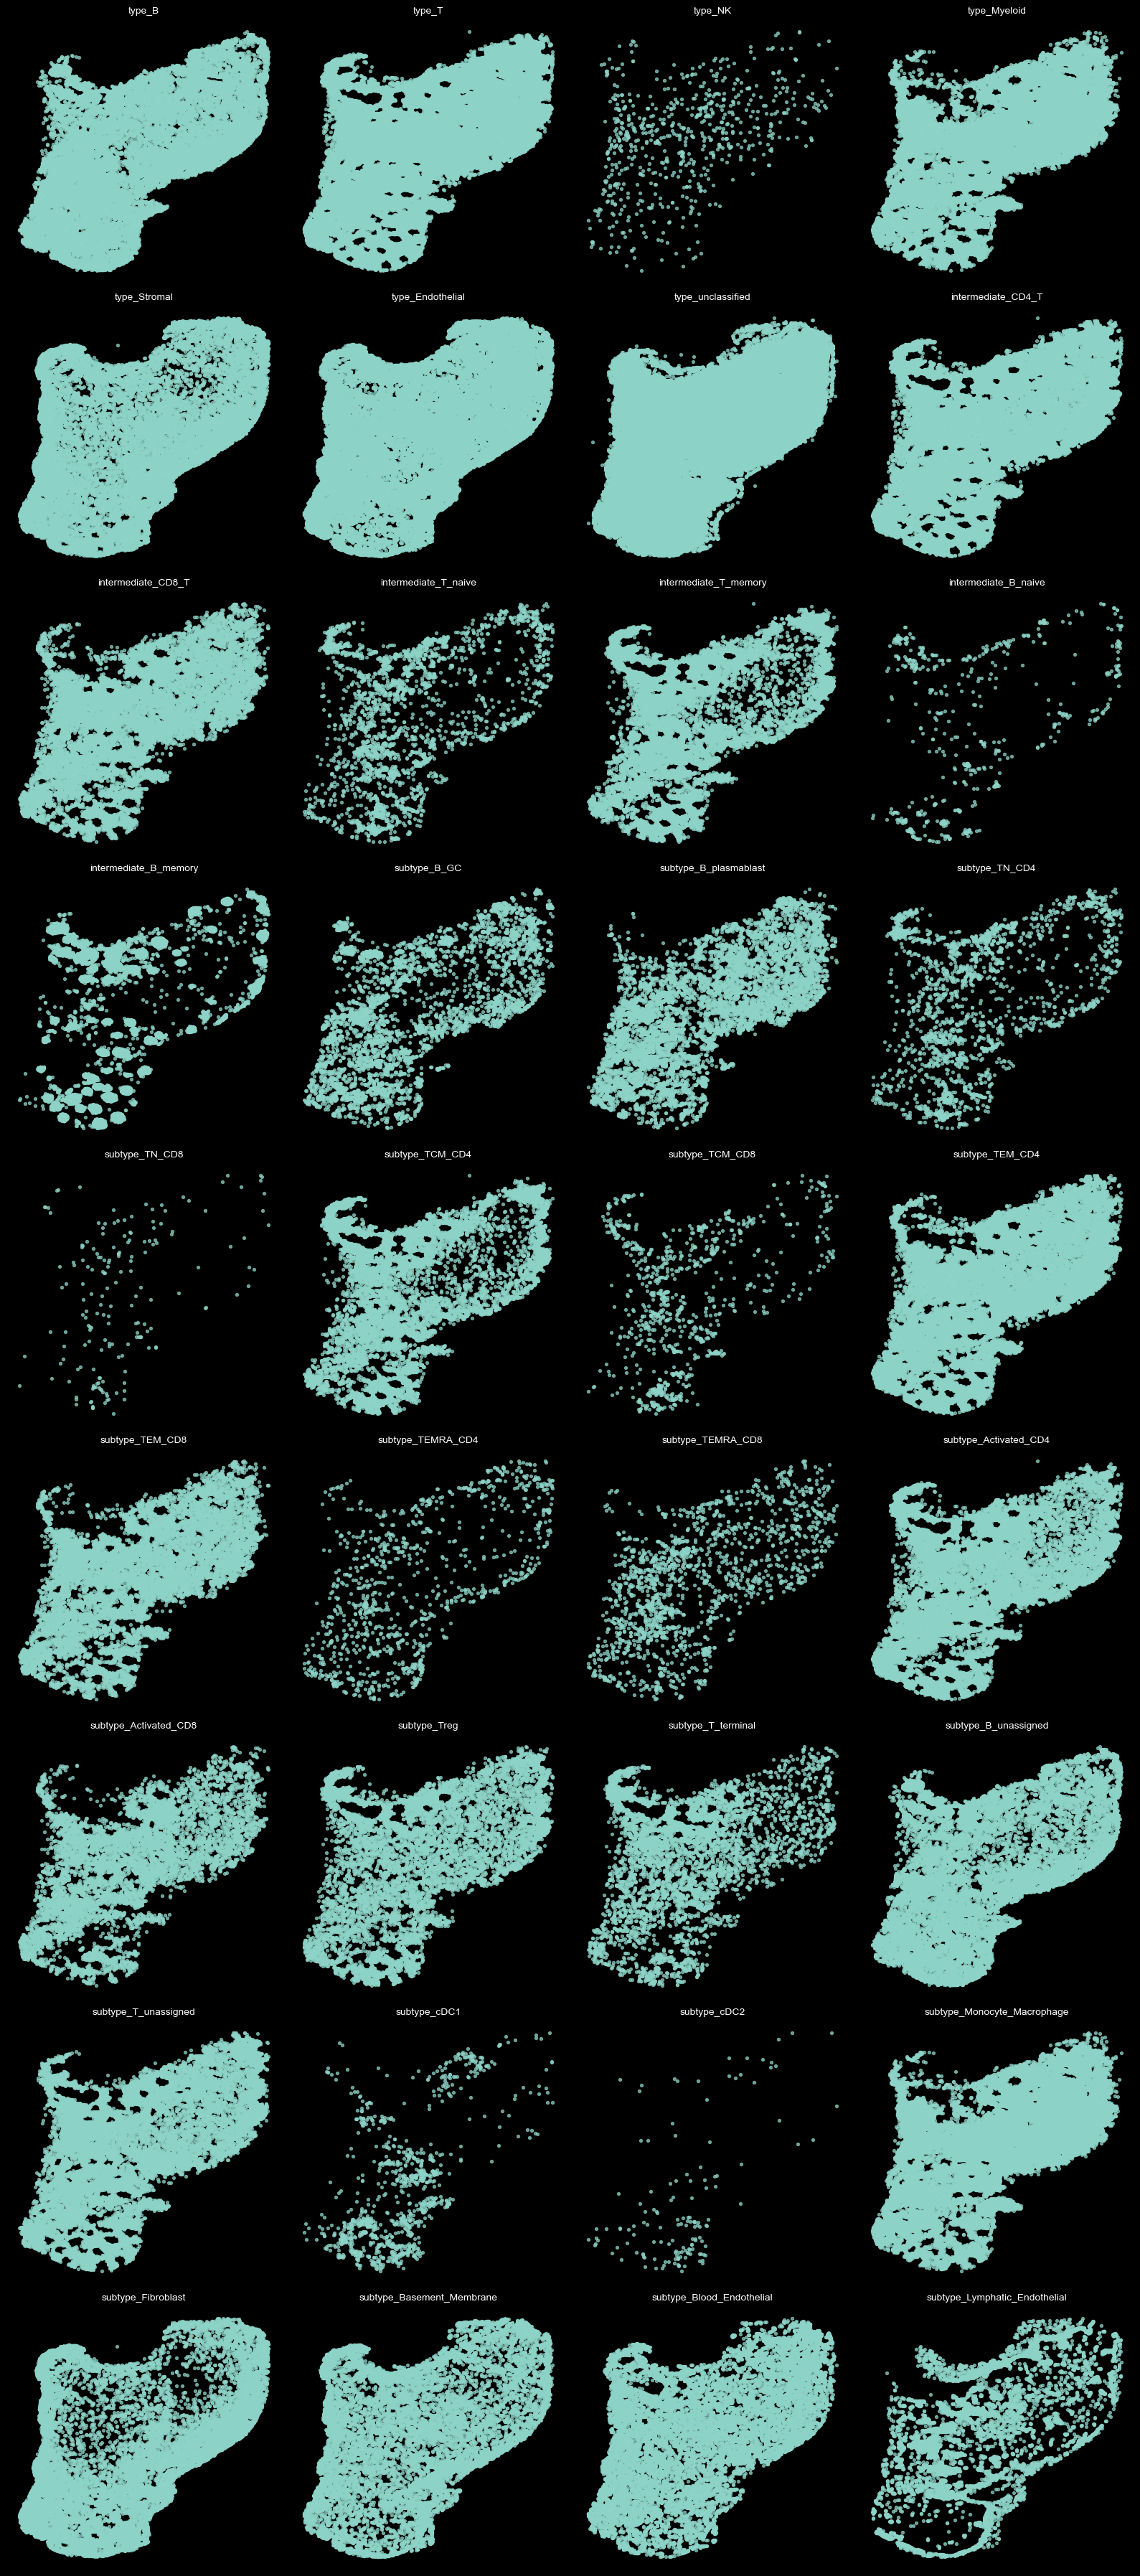

In [126]:
from scripts.spatial_plot import spatial_celltype_plot

import math
import matplotlib.pyplot as plt

celltypes = (
    [c for c in adata.obs.columns if c.startswith("type_")] +
    [c for c in adata.obs.columns if c.startswith("intermediate_")] +
    [c for c in adata.obs.columns if c.startswith("subtype_")]
)

# Filter by min_cells
celltypes = [c for c in celltypes if adata.obs[c].sum() >= 15]

n = len(celltypes)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))

axes = axes.flatten()

for ax, ct in zip(axes, celltypes):

    mask = adata.obs[ct].astype(bool)

    ax.scatter(
        adata.obs.loc[mask, "x"],
        adata.obs.loc[mask, "y"],
        s=8,
        alpha=0.7
    )

    ax.set_title(ct, fontsize=10)
    ax.invert_yaxis()
    ax.axis("off")

# remove empty panels
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [127]:
print(f"{basename}_spatial_grid")


IHOPE14_MedLN_BottomRight_spatial_grid


# Cell type summary in sample

Use after loading data and running annotation!

This will be used later for statistical comparison between tissues.

In [128]:
from scripts import summary_celltypes_IHOPE
importlib.reload(scripts.summary_celltypes_IHOPE)

<module 'scripts.summary_celltypes_IHOPE' from 'D:\\Emmy\\IHOPE_SpatialProteomics\\scripts\\summary_celltypes_IHOPE.py'>

In [129]:
from scripts.summary_celltypes_IHOPE import summarize_celltypes_IHOPE

df_summary = summarize_celltypes_IHOPE(
    adata,
    filename=f"{basename}_filtered_arcsinh_cf5.0_IHOPE_summary.csv"
)


Cell type summary written to:
  D:\Emmy\IHOPE_SpatialProteomics\results\reports\celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_summary.csv

Cell type summary:
       level             cell_type                        column  n_cells  pct_total  total_cells
        type          unclassified             type_unclassified   137890       34.5       399569
        type                     T                        type_T    87907       22.0       399569
        type           Endothelial              type_Endothelial    61143       15.3       399569
        type                     B                        type_B    49687       12.4       399569
        type               Myeloid                  type_Myeloid    41398       10.4       399569
        type               Stromal                  type_Stromal    29204        7.3       399569
        type                    NK                       type_NK      694        0.2       399569
intermediate                 CD4

# Comparison

Time to compare between samples!

In [88]:
import importlib
import scripts.comparison as comparison

importlib.reload(comparison)

from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
)



Cell type percentage summary (% of total cells):

sample                         IHOPE20_LN  IHOPE26_LN  IHOPE27_LN  IHOPE39_LN
level   cell_type                                                            
state   B_CD27neg_naive_like          0.9        17.8         3.2         0.6
        B_CD27pos_memory_like        30.9        12.5         4.1        25.6
        B_GC_like                     0.3         0.1         0.0         0.3
        B_plasmablast_like            0.5         1.0         1.1         0.8
        B_resting                     0.0         0.0         0.0         0.0
        T_memory                     16.6        22.8        10.3        31.0
        T_naive                      26.5         7.2        36.8        22.5
subtype B_GC_like                     0.3         0.1         0.0         0.3
        B_memory_like                 0.0         0.0         0.0         0.0
        B_naive_like                  0.0         0.0         0.0         0.0
        B_pla

/Users/magnusberg/Documents/MTLS/Degree/IHOPE_SpatialProteomics/scripts/comparison.py:160: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.show()


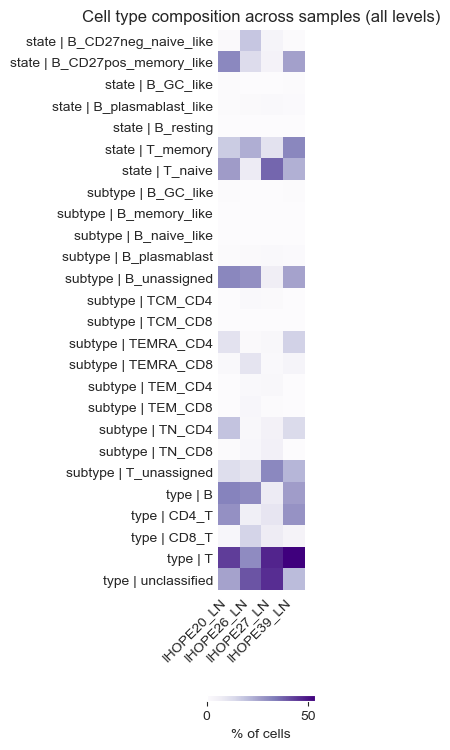

In [89]:
df = load_celltype_summaries(
    summaries_dir=summaries_dir,
    basenames=basenames,
)

print_numeric_summary(df)

matrix = pivot_for_heatmap(df)

plot_celltype_heatmap(
    matrix,
    title="Cell type composition across samples (all levels)",
)


# BANKSY
For this part you need a saved .h5ad file containing an anndata object, and Python 12 is required (not a later version of Python). Note that BANKSY only identifies spatial domains and not cell types. This section provides the workflow from AnnData object to BANKSY domains, which can be used as a foundation for further analysis.

In [4]:
import sys
from pathlib import Path

#Specific
PROJECT_ROOT = Path("")

In [ ]:
basename = "IHOPE14_MedLN_BottomLeft"

In [130]:
print(basename)

IHOPE14_MedLN_BottomRight



Median distance to closest cell = 6.628725367670477

---- Ran median_dist_to_nearest_neighbour in 0.91 s ----

---- Ran generate_spatial_distance_graph in 2.16 s ----

---- Ran row_normalize in 0.52 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 5.93 s ----

----- Plotting Edge Histograms for m = 0 -----

Edge weights (distances between cells): median = 13.897481786280391, mode = 7.47133850467012

---- Ran plot_edge_histogram in 0.18 s ----


Edge weights (weights between cells): median = 0.0584418481797191, mode = 0.03183233867890193

---- Ran plot_edge_histogram in 0.17 s ----

---- Ran generate_spatial_distance_graph in 3.30 s ----

---- Ran theta_from_spatial_graph in 1.54 s ----

---- Ran row_normalize in 0.52 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 8.98 s ----

----- Plotting Edge Histograms for m = 1 -----

Edge weights (distances between cells): median = 19.318643844741956, mode = 14.66791823762673

---- Ran plot_edge_histogram in 0.35 s ----



C:\Users\emmy.berg\AppData\Local\miniconda3\envs\ihopespatial\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\emmy.berg\AppData\Local\miniconda3\envs\ihopespatial\lib\site-packages\numpy\lib\histograms.py:841: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
C:\Users\emmy.berg\AppData\Local\miniconda3\envs\ihopespatial\lib\site-packages\matplotlib\axes\_axes.py:7135: ComplexWarning: Casting complex values to real discards the imaginary part
  bins = np.array(bins, float)  # causes problems if float16
C:\Users\emmy.berg\AppData\Local\miniconda3\envs\ihopespatial\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)



Edge weights (weights between cells): median = (-2.2679863702313e-09-0.05188548017175214j), mode = -0.012156295807459208

---- Ran plot_edge_histogram in 0.72 s ----

----- Plotting Weights Graph -----
Maximum weight: 0.19895211604226345

---- Ran plot_graph_weights in 37.94 s ----

Maximum weight: (0.08810297402304627-0.017830364045512217j)

---- Ran plot_graph_weights in 71.32 s ----

----- Plotting theta Graph -----


TypeError: run_banksy_multiparam() missing 4 required positional arguments: 'color_list', 'max_m', 'filepath', and 'key'

C:\Users\emmy.berg\AppData\Local\miniconda3\envs\ihopespatial\lib\site-packages\matplotlib\collections.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  renderer.draw_path_collection(


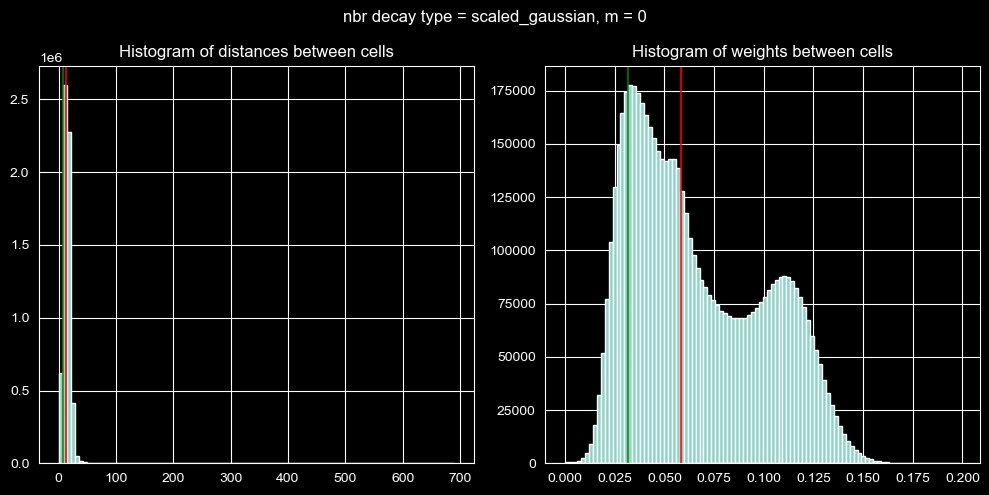

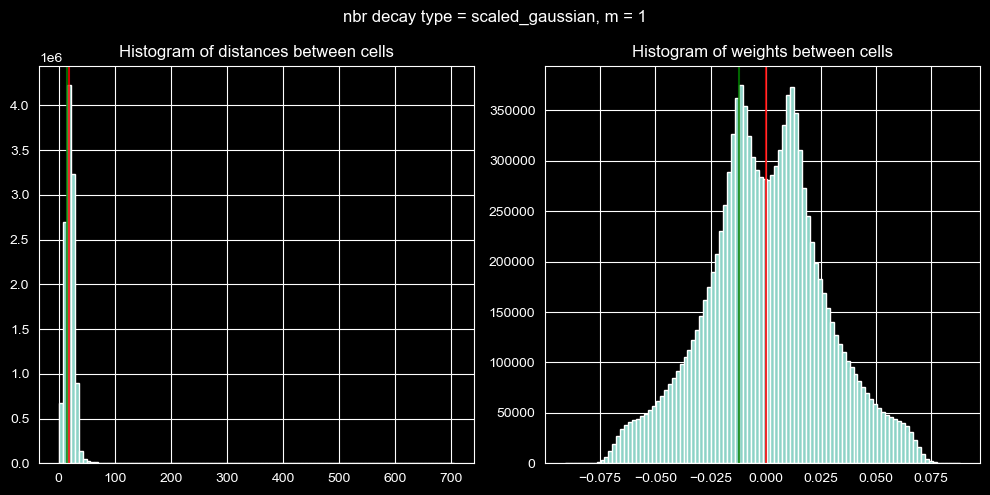

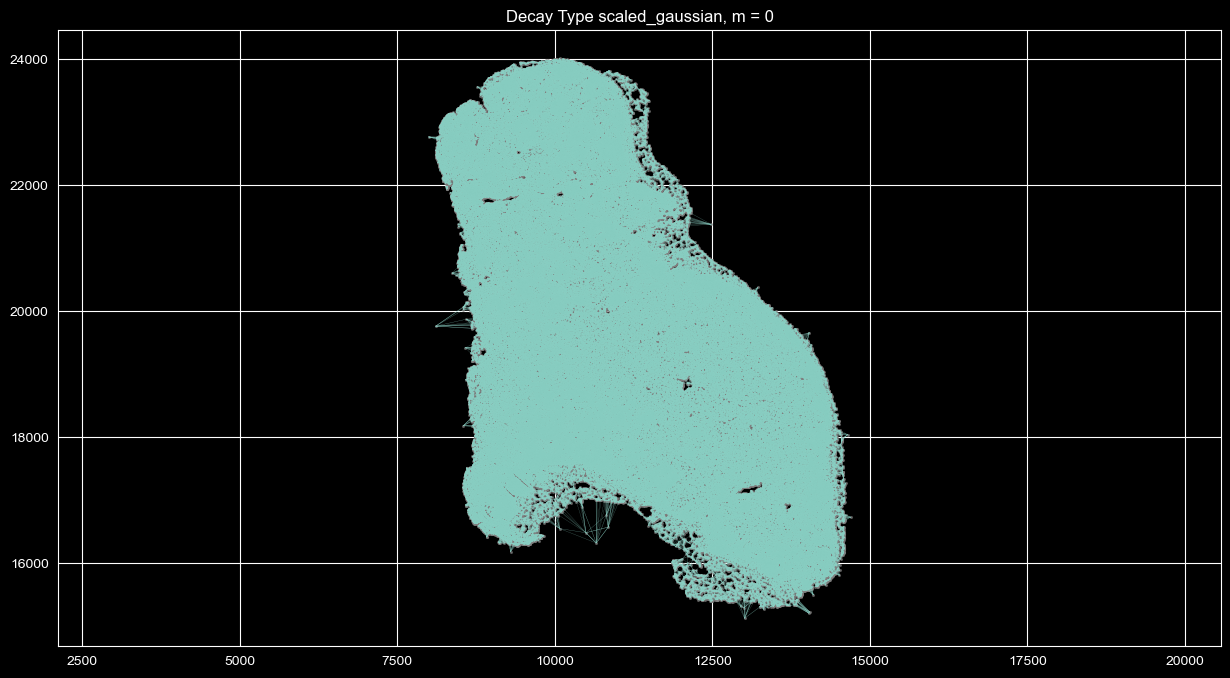

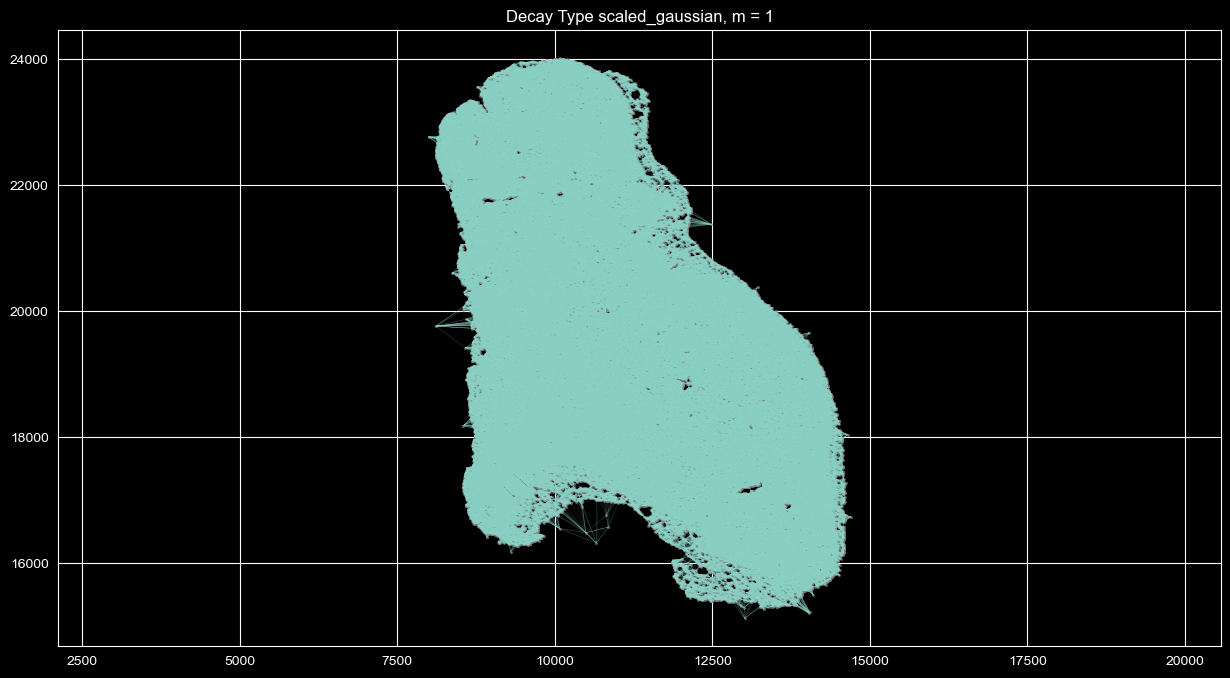

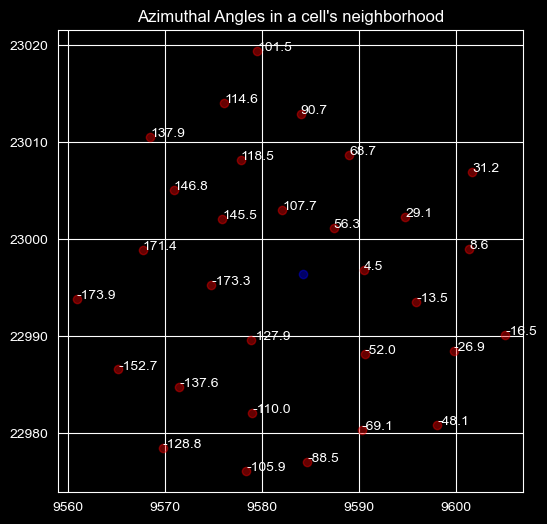

In [131]:
import banksy
import scanpy as sc

from banksy.initialize_banksy import initialize_banksy
from banksy.run_banksy import run_banksy_multiparam


h5ad_file = PROJECT_ROOT / "data" / "processed" / "anndata" / f"{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes.h5ad"

# Load your spatial transcriptomics data
adata = sc.read_h5ad(h5ad_file)

# Initialize BANKSY
coord_keys = ('x', 'y', 'spatial')
banksy_dict = initialize_banksy(
    adata,
    coord_keys=coord_keys,
    num_neighbours=15,
    nbr_weight_decay='scaled_gaussian'
)

# Run BANKSY clustering

results_df = run_banksy_multiparam(
    adata,
    banksy_dict,
    lambda_list=[0.2],
    resolutions=[0.5, 1.0]
)


Median distance to closest cell = 6.628725367670477

---- Ran median_dist_to_nearest_neighbour in 0.91 s ----


Median distance to closest cell = 6.628725367670477

---- Ran median_dist_to_nearest_neighbour in 0.92 s ----

---- Ran generate_spatial_distance_graph in 2.20 s ----

---- Ran row_normalize in 0.53 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 6.02 s ----

---- Ran generate_spatial_distance_graph in 3.31 s ----

---- Ran theta_from_spatial_graph in 1.49 s ----

---- Ran row_normalize in 0.53 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 8.89 s ----

----- Plotting Weights Graph -----
Maximum weight: 0.19895211604226345

---- Ran plot_graph_weights in 39.75 s ----

Maximum weight: (0.08810297402304627-0.017830364045512217j)

---- Ran plot_graph_weights in 72.26 s ----

Runtime Mar-06-2026-11-16

38 genes to be analysed:
Gene List:
Index(['arcsinh_cf5.0_CCR6', 'arcsinh_cf5.0_CCR7', 'arcsinh_cf5.0_CD107a',
       'arcsinh_cf5.0_CD11c', 'arcsinh_cf5.0_CD14',

C:\Users\emmy.berg\AppData\Local\miniconda3\envs\ihopespatial\lib\site-packages\banksy\labels.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  expand_labels(label_list[sort_indices[0]],


,decay,lambda_param,num_pcs,resolution,num_labels,labels,adata,relabeled
scaled_gaussian_pc20_nc0.80_r0.50,scaled_gaussian,0.8,20,0.5,12,"Label object:\nNumber of labels: 12, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 12, number of..."


C:\Users\emmy.berg\AppData\Local\Temp\ipykernel_17588\2960803344.py:67: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='banksy_domain', spot_size=30, title='BANKSY Domains')


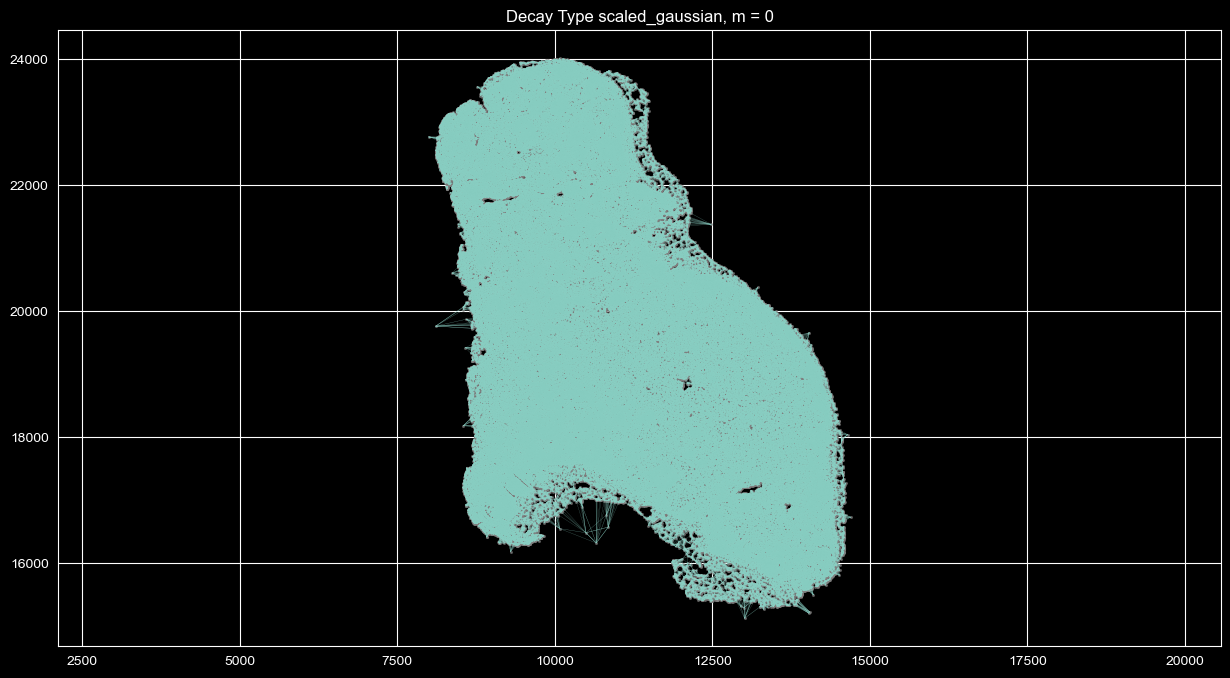

C:\Users\emmy.berg\AppData\Local\miniconda3\envs\ihopespatial\lib\site-packages\matplotlib\collections.py:430: ComplexWarning: Casting complex values to real discards the imaginary part
  renderer.draw_path_collection(


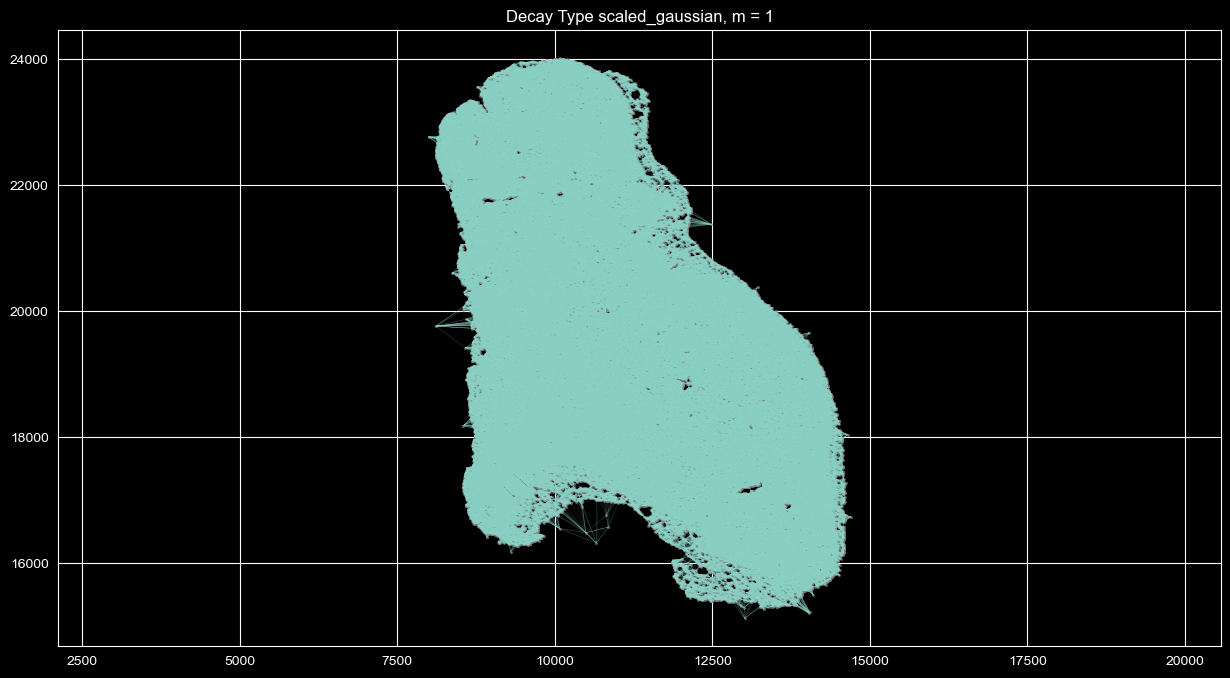

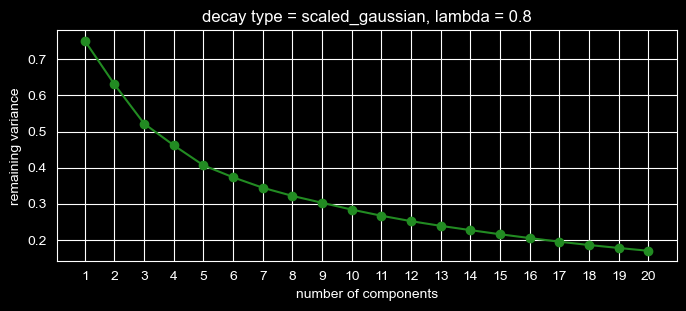

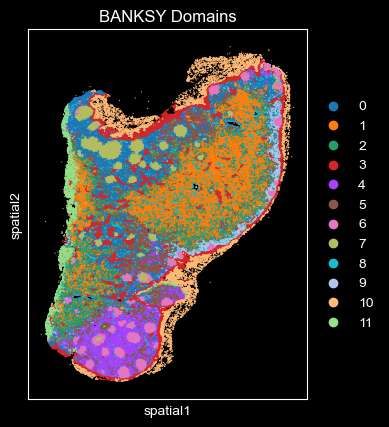

BANKSY complete for IHOPE14_MedLN_BottomRight! Domains added to `adata.obs['banksy_domain']`


In [132]:
from banksy.main import median_dist_to_nearest_neighbour
from banksy.initialize_banksy import initialize_banksy
from banksy.embed_banksy import generate_banksy_matrix
from banksy_utils.umap_pca import pca_umap
from banksy.cluster_methods import run_Leiden_partition
from banksy.plot_banksy import plot_results

# Parameters for BANKSY
coord_keys = ('x', 'y', 'spatial')
k_geom = 15
max_m = 1
nbr_weight_decay = "scaled_gaussian"
lambda_list = [0.8]
resolutions = [0.5]       # Leiden clustering resolution
pca_dims = [20]             # Try a lower number?
cluster_algorithm = 'leiden'
cmap = 'tab20'             # color map for spatial plotting
save_path = None           # e.g., "./BANKSY_results" if you want to save figures

# Compute neighbor distances
nbrs = median_dist_to_nearest_neighbour(adata, key=coord_keys[2])

# Initialize BANKSY
banksy_dict = initialize_banksy(
    adata,
    coord_keys,
    k_geom,
    nbr_weight_decay=nbr_weight_decay,
    max_m=max_m,
    plt_edge_hist=False,
    plt_nbr_weights=True,
    plt_agf_angles=False,
    plt_theta=False
)

# Generate BANKSY matrix
banksy_dict, banksy_matrix = generate_banksy_matrix(
    adata,
    banksy_dict,
    lambda_list,
    max_m
)

# Dimensionality reduction by UMAP
pca_umap(
    banksy_dict,
    pca_dims=pca_dims,
    add_umap=True
)

# Run Leiden clustering
results_df, max_num_labels = run_Leiden_partition(
    banksy_dict,
    resolutions=resolutions,
    num_nn=50,
    num_iterations=-1,
    partition_seed=1234,
    match_labels=True,
    max_labels=None
)

# Map clusters back to adata
cluster_labels = results_df.labels[results_df.index[0]].dense
adata.obs['banksy_domain'] = cluster_labels.astype(str)

# Optional: visualize
sc.pl.spatial(adata, color='banksy_domain', spot_size=30, title='BANKSY Domains')

# Optional: use BANKSY plotting function
if save_path is not None:
    os.makedirs(save_path, exist_ok=True)
    weights_graph = banksy_dict['scaled_gaussian']['weights'][1]
    plot_results(
        results_df[results_df['num_labels']==len(np.unique(cluster_labels))],
        weights_graph,
        cmap,
        match_labels=True,
        coord_keys=coord_keys,
        max_num_labels=max_num_labels,
        save_path=save_path,
        save_fig=True,
        save_fullfig=True,
        dataset_name='Sample',
        save_labels=True
    )

print(f"BANKSY complete for {basename}! Domains added to `adata.obs['banksy_domain']`")

Save anndata object with BANKSY domains

In [133]:
h5adpath = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes_banksy.h5ad"
save_h5ad(adata, h5adpath)

# B-cell follicle identification

Identify B-cell enriched domains and the cell types that require BANKSY information

In [134]:
import importlib
import scripts.banksy_domains

# Reload the module after editing
importlib.reload(scripts.banksy_domains)

<module 'scripts.banksy_domains' from 'D:\\Emmy\\IHOPE_SpatialProteomics\\scripts\\banksy_domains.py'>

All BANKSY domains:

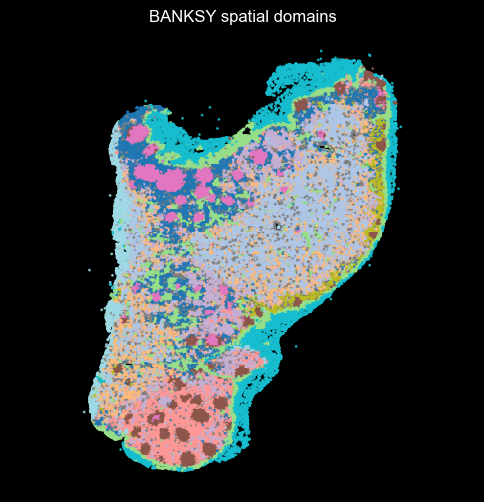

In [135]:
from scripts.banksy_domains import plot_banksy_domains

plot_banksy_domains(adata)

In [136]:
print(f"{basename}_BANKSY_domains.png")

IHOPE14_MedLN_BottomRight_BANKSY_domains.png


D:\Emmy\IHOPE_SpatialProteomics\scripts\banksy_domains.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for domain, idx in adata.obs.groupby(banksy_domain_key).groups.items():


Identified 1 B-cell–enriched domains (≥50% B cells)


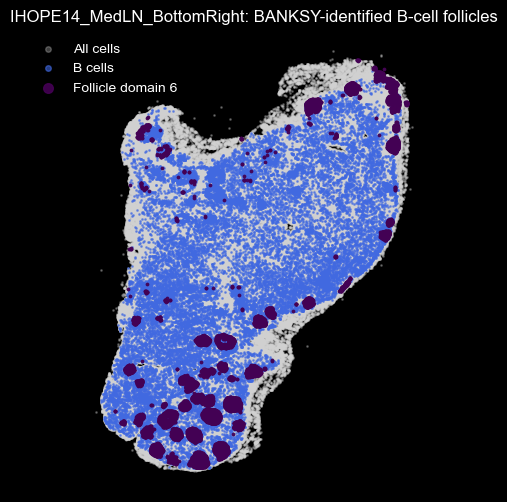

In [137]:
# Identify follicles (once per BANKSY run)
from scripts.banksy_domains import identify_bcell_follicles, plot_bcell_follicles

min_fraction = 0.5

adata, follicle_stats = identify_bcell_follicles(
    adata,
    banksy_domain_key="banksy_domain",
    min_fraction_bcells=min_fraction,
)

plot_bcell_follicles(adata, sample_name = basename)

In [139]:
print(f"{basename}_BANKSY_Bcell_frac_{min_fraction}_domains.png")

IHOPE14_MedLN_BottomRight_BANKSY_Bcell_frac_0.5_domains.png


In [140]:
import importlib
import scripts.celltype_rules_IHOPE
importlib.reload(scripts.celltype_rules_IHOPE)


<module 'scripts.celltype_rules_IHOPE' from 'D:\\Emmy\\IHOPE_SpatialProteomics\\scripts\\celltype_rules_IHOPE.py'>

TfH-like cells: 18 (0.00% of all cells)


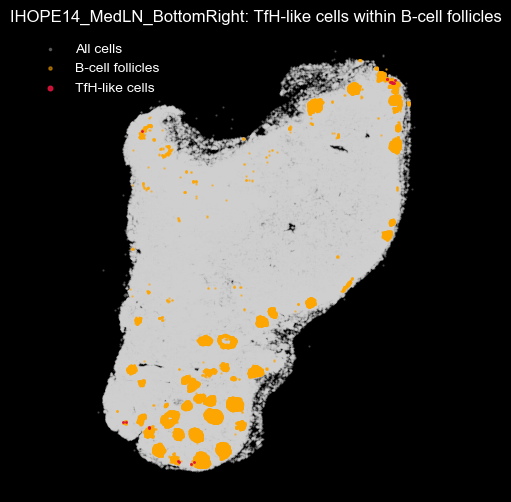

In [141]:
# Add TfH-like cells
from scripts.celltype_rules_IHOPE import add_TfH_like_cells

adata = add_TfH_like_cells(
    adata,
    follicle_key="B_follicle",
    plot=True,
    size=0.3,
    sample_name = basename
)


Named as:

In [142]:
print(f"{basename}_TfH_spatial_minfrac_Bc_{min_fraction}.png")

IHOPE14_MedLN_BottomRight_TfH_spatial_minfrac_Bc_0.5.png


Finally, save the updated anndata object with the TfH cells added.

In [143]:
h5adpath = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes_banksy_TfH.h5ad"
save_h5ad(adata, h5adpath)

New cell type summary

In [144]:
from scripts.summary_celltypes_IHOPE import summarize_celltypes_IHOPE

df_summary = summarize_celltypes_IHOPE(
    adata,
    filename=f"{basename}_filtered_arcsinh_cf5.0_IHOPE_summary_withTfH.csv"
)


Cell type summary written to:
  D:\Emmy\IHOPE_SpatialProteomics\results\reports\celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_summary_withTfH.csv

Cell type summary:
       level             cell_type                        column  n_cells  pct_total  total_cells
        type          unclassified             type_unclassified   137890       34.5       399569
        type                     T                        type_T    87907       22.0       399569
        type           Endothelial              type_Endothelial    61143       15.3       399569
        type                     B                        type_B    49687       12.4       399569
        type               Myeloid                  type_Myeloid    41398       10.4       399569
        type               Stromal                  type_Stromal    29204        7.3       399569
        type                    NK                       type_NK      694        0.2       399569
intermediate            